# Armonic: Syntétisation de notes de guitare

## Introduction

De nombreux logiciels permettent la production de musique électronique sans avoir à jouer d'un instrument. Ces logiciels reposent en partie en l'implantation de sons simulant parfois des instruments de musique, comme par exemple des notes de piano ou des notes de guitare, que l'on peut assembler pour former des accords, une mélodie... etc. 

On se pose la question de s'il est possible de produire le phénomène physique du son d'un instrument à corde à travers des méthodes numériques : nous chercherons à l'aide d'un programme python, à générer une note de guitare, dans un premier temps en simulant entièrement le signal puis à partir de l'étude d'enregistrements, en se basant sur la décomposition en transformée de Fourier (discrète) d'un son.

## I. Théorie & Première modélisation

La corde vibrante est le modèle physique permettant de représenter les mouvements d'oscillation d'un fil tendu, ici, une corde de guitare fixée à ses deux extrémités. Lorsqu'on pince la corde au dessus de la caisse de résonnance, puis, qu'on la relâche, on a la propagation d'une onde de déplacement, une onde de vitesse ainsi qu'une onde de tension qui se réfléchissent de part et d'autres des extrémités de la corde, mais qui se transmettent également à l'air (onde de supression), responsabe du son effectué. 

L'onde sur la corde peut donc être modélisée par une superposition d'ondes stationnaires unidimensionnelles (onde transverse se propagaeant le long de l'axe $Ox$). On peut donc décomposer le signal sur une base de sinus et de cosinus (décomposition en série de fourier) ainsi :  

$$y(x,t) = \sum_{n=1}^{\infty} {\mathcal{B_n} \sin(k_nx)\cos(\omega_n t) + \mathcal{C_n} \sin(k_nx)\sin(\omega_n t)} $$ 

où $\mathcal{B_n}$ et $\mathcal{C_n}$ sont des coefficients déterminés par les conditions initiales :

$$B_n = \frac {2} {l} \int_0^l {u(x,t=0)\sin(k_nx)dx}$$

$$w_n C_n = \frac {2} {l} \int_0^l {\frac { \partial u(x,t=0)} {\partial t} \sin(k_nx)dx}$$

où $y_n$ est appelé mode. 




Nous aurons besoins de différents paramètres et constantes : 
- La longueur de la corde, que l'on mesure à $l = 0.755m$ pour une corde de La
- La hauteur de la corde lorsqu'on réalise le pincement, que l'on estimme à 1/2cm pour un pincement au centre de la caisse de résonnance (1/4 de l) 
- La vitesse du son dans la corde :

$$c = \sqrt{\frac {T_0}{\mu}}$$ 

où $T_0 = 80 N$ la tension au repos dans la corde, et $\mu = 0.001 \text{ kg/m}$ la masse linéique de la corde.

- La fréquence de la note qu'on souhaite générer, ici $\nu = 110 \text{ Hz}$ pour un La

In [1]:
# Import des modules
import numpy as np
import matplotlib.pyplot as plt
import os # permet de localiser les fichiers localement dans l'ordinateur

from scipy.io import wavfile #Module permettant d'enregistrer au format WAV
import scipy.io as spyo

from numpy.fft import fft, fftfreq #Module permettant de réaliser la transformée
from scipy.signal import find_peaks #Module permettant de trouver les maximas
from scipy.signal import butter, filtfilt #Module permettant d'ajouter un filtre passe-bas

In [2]:
def initialiser_modele():
    """Fonction définissant les conditions initiales"""

    h = 1/2 * 10**(-2) #m, hauteur de la perturbation 
    l = 0.755 #Longueur de la corde (on a mesuré 75.5cm pour un La)
    a = 0 #borne d'intégration
    nu = 110 #Hz, Fréquence d'un La
    T = 78.7 #N Tension dans la corde
    mu = 3.79*0.001 #kg/m masse linéique dans la corde 
    c = np.sqrt(T / mu) #m/s vitesse de l'onde dans la corde
    k = 1000 #pas pour l'intégration
    nbr_modes = 30 #nombre de modes
    
    return h, l, a, nu, T, mu, c, k, nbr_modes


On a pour une onde stationnaire $$y(x,t) = \left( \text {A} \cos(k_nx) + \text{B} \sin(k_nx) \right) \cos(\omega_n t)$$

Or, on a pour conditions limites :
- $y(0,t) = 0$, ce qui implique $\text {A} \cos(\omega_n t) = 0$ pour tout t, et donc $A = 0$
- $y(L,t) = 0$, ce qui implique $\text{B} \sin(k_n L) \cos(\omega_n t) = 0$ et donc $\sin(k_n L) = 0$ 

Donc $$k_n = n \pi / l$$

 le nombre d'onde de chaque mode (avec l la longueur de la corde), et $w_n = 2\pi n \nu$ la pulsation du mode (où $\nu$ est la fréquence fondamentale)

On a comme conditions initiales classiques pour une corde de guitare : 

$$
\left\{
\begin{array}{rcr}
 u(x,t=0) = \frac {4hx}{l} \text{,   } x \le l/4 \\
 \\
 u(x,t=0) = \frac {4(l-x)h}{3l} \text{  sinon} \\
\end{array}
\right.
$$


et $$ \frac {\partial u(x,t=0)} {\partial t} = 0$$

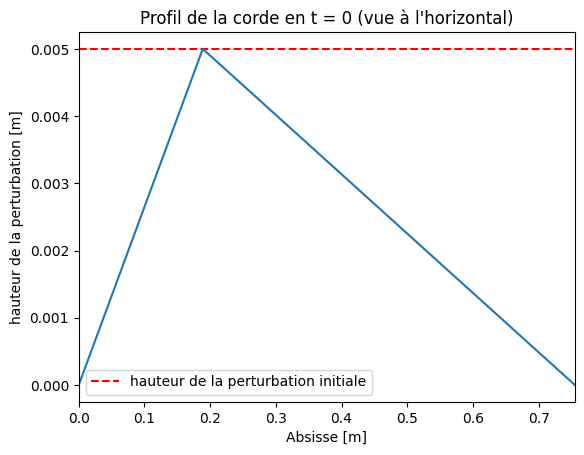

In [3]:
h, l, a, nu, T, mu, c, k, nbr_modes = initialiser_modele() #définitions des paramètres

def u(x, n, l, h):
    """Profil triangulaire centré en x = l/4"""
    if x <= l/4:
        return (4*h/l) * x
    else:
        return 4*h/(3*l)*(l-x)

def du(x):
    """Conditions initiales régulières pour une corde de guitare (onde de vitesse)"""
    return np.zeros_like(x)


#Définition des paramètres du problème
def kn(n):
    """Nombre d'onde de chaque mode"""
    return  np.pi*n/l

def wn(n):
    """Pulsation propre de chaque mode"""
    return 2*np.pi*n*nu

#Fonctions à intérer pour calculer les coefficients
def dBn(x,n,l,h):
    """Fonction à intégrer pour calculer B_n"""
    return u(x,n,l,h)*np.sin(kn(n)*x) 

def dCn(x,n,l,h):
    """Fonction à intégrer pour calculer C_n"""
    return du(x)*np.sin(kn(n)*x)

#Tracé du profil de la corde en t=0
x = np.linspace(0,l,1000)
z = []
for i in x:
    z.append(u(i, 1,l,h))

plt.title("Profil de la corde en t = 0 (vue à l'horizontal)")
plt.xlabel('Absisse [m]')
plt.ylabel('hauteur de la perturbation [m]')
plt.axhline(0.005, label ='hauteur de la perturbation initiale', color ='r', linestyle ='--')
plt.plot(x, z)
plt.legend()
plt.xlim(0,l)
plt.show()


In [4]:
# Fonction intégration:
def int_t(f, a, b, k, l, n, h):
    """Intégration par méthode des trapèzes"""
    deltax = (b - a) / k
    somme = 0
    for i in range(k):
        somme = somme + (f(a + i * deltax,n,l,h) + f(a + (i + 1) * deltax,n,l,h)) * deltax / 2
    return somme

In [5]:
sample_rate = 44100 #Sample rate en Hz (nombre d'échantilons par seconde)
duree = 10.         #Durée de la simulation [en s]

t = np.linspace(0, duree, int(sample_rate * duree)) #Tableau de temps

Pour mieux imiter l'instrument, nous pouvons  également ajouter un amortissement pour chaque mode, couplé à une attaque : 

- $\text{attack(t)} = \frac {t} {0.1}$ jusqu'à t = 0.1s sur une première (courte) partie du signal, acroissement linéaire de l'amplitude du son.
- $\text{decay(t)} = \frac {1} {1+(\frac {t} {0.25})^{2}}$ amortissement de type lorentzien sur la seconde partie du signal (de t = 0.1s à la fin).

On regroupe ces deux tableau en 1, et on le multiplie avec le profil temporel de chaque mode.

Pour améliorer le son obtenu, nous avons également appliqué un filtre passe bas à 5000Hz, là où s'arrêtent typiquement les modes d'une guitare.

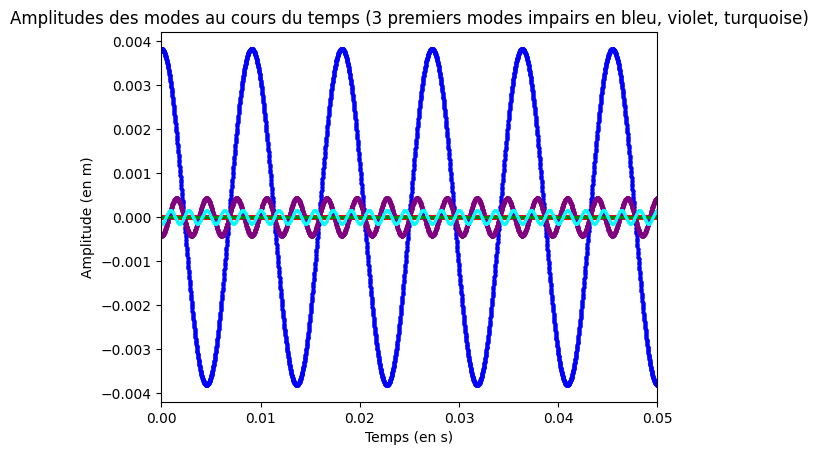

In [6]:
Bn = np.zeros((nbr_modes,)) #Tableau vide contenant les Bn
for n in range(1,nbr_modes+1):
  Bn[n-1] = (2/l) * int_t(dBn, 0, l, k, l, n, h) #Calcul du coefficient pour chaque n et ajout au tableau
  
wnCn = np.zeros((nbr_modes,)) #Tableau vide contennant les wnCn
for n in range(1,nbr_modes+1):
  wnCn[n-1] = 2/l*int_t(dCn, a, l, k,l,n,h) #Calcul du coefficient pour chaque n et ajout au tableau


def y_n(t,wn,kn,B,C, x = l/2):
  """Fonction calculant le mode en x = l/2, pour n donné"""
  return B*np.sin(kn*x)*np.cos(wn*t)+C*np.sin(kn*x)*np.sin(wn*t) #On réalise les calculs pour x = l/2


yn = np.zeros((nbr_modes, len(t))) # Tableau vide contenant les modes
for n in range(1, nbr_modes + 1):
  yn[n-1, :] = y_n(t, wn(n), kn(n), Bn[n-1], wnCn[n-1]) # Calcul du mode pour chaque n

y = np.sum(yn,axis=0) #somme des modes sur la 1ere dimension (n et non pas t)

#Ajout de l'attaque et de l'amortissement
attack = np.linspace(0, 1, int(0.1*sample_rate)) #tableau de valeurs allant linéairement de 0 à 1 jusqu'à t = 0.1s
t_fin = np.linspace(0, 5, len(y)-len(attack)) #tableau de temps allant de 0.1s à la fin de l'enregistrement
decay = (1/(1+(t_fin/0.25)**2)) 
y_filtered = y*np.concatenate([attack, decay]) 

#Ajout d'un filtre passe bas à 5 kHz
b, A = butter(4, 5000/(sample_rate/2), 'low', analog = True)  #coefficients du filtre "passe bas" (d'ordre 4)
y_filtered = filtfilt(b, A, y_filtered) #application du filtre


#Tracé des différents modes
plt.title('Amplitudes des modes au cours du temps (3 premiers modes impairs en bleu, violet, turquoise)')
plt.xlabel('Temps (en s)')
plt.ylabel('Amplitude (en m)')
plt.scatter(t,yn[0], s = 5, color ='b')
plt.scatter(t,yn[1], s = 5, color ='r')
plt.scatter(t,yn[2], s = 5, color ='purple')
plt.scatter(t,yn[3], s = 1, color ='green')
plt.scatter(t,yn[4], s = 1, color ='cyan')
plt.xlim(0,0.05)
plt.show()

Le calcul analytique donne pour $n \in \mathbb{N^*}$ $$B_n =  \frac {32h\sin(n\pi / 4)}{3 \pi^2 n^2}$$ $$C_n = 0$$

Les résultats obtenus sont complètement cohérents avec ce que l'on était sensé obtenir, on a bien une décroissance rapide de l'amplitude du mode avec n (en particulier n²), et d'où le fait que les modes pairs soient nuls.

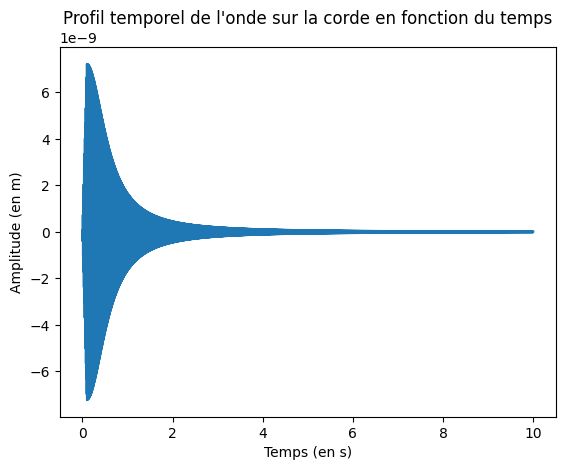

In [7]:
plt.plot(t,y_filtered)
plt.title("Profil temporel de l'onde sur la corde en fonction du temps")
plt.xlabel('Temps (en s)')
plt.ylabel('Amplitude (en m)')
plt.show()

On peut ensuite transformer cette onde de déplacement en son au format WAV :

In [8]:
def save_wav(data , filename ="Default_name", multichannel = False, sample_rate = 44100):
    """Sauvegarde customisée d'un tableau numpy a wav"""

        # Mise en forme des données
    if multichannel == True:
        data = data.T

    elif multichannel == False & data.ndim>1:
        data = np.sum(data, axis = 0)

        #else:
        #    data = data

        # Normalisation des données et détermination du type
    data_normalized = (data / np.max(np.abs(data))).astype(np.float32)

    # Sauvegarde en wav
    spyo.wavfile.write(filename, sample_rate, data_normalized)

In [9]:
#Sauvegarde au format WAV
save_wav(y_filtered, filename = "Fourier simulé")

On voit bien que les autres modes que les modes fondamentaux n'apparaissent pas réellement sur le graphe : cela s'entend également lorsqu'on joue le fichier, le son est particulièrement pur et proche de celui du diapason. Les modes impairs sont également tous nuls, ce qui est lié à la condition initiale sur l'onde de vitesse.
Autre problème : on a ici le profil temporel de l'onde de déplacement en x = l/2. Cependant, cela correspond à l'onde sur la corde, et pas l'onde acoustique de surpression que l'on entend.
En toute rigueur, on devrait prendre en compte la transmission du son à l'air afin d'obtenir une onde acoustique. Cette méthode ne semble donc pas être la plus appropriée et il serait plus pertinent de partir d'une onde de surpression dès le départ.

## II. Extraction des modes d'un enregistrement : simulation d'un son

Dans la première partie nous avions essayé de recréer l'onde sonore produite par la vibration de la corde à partir simplement des conditions initiales d'excitation connues, et la décomposition d'un signal en série de Fourier.

Cependant, même si nous parvenions à simuler la transmission de l'onde à l'air, cette méthode pose un problème pour la bonne simulation du son d'une guitare: elle ne permet pas réellement la simultaion du timbre. 

En effet, une note de musique est caractérisée de façon générale par :
- sa hauteur: la fréquence foncdamentale de la note.
- son intensité: amplitude de l'onde de surpression produite par le passage de l'onde de pression
- son timbre: caractéristique de chaque type d'intrument (guitare, piano...). Il est défini par la forme du motif sonore (motif temporel). 

La forme du timbre sonore est déterminée par la contribution de chaque mode à la note finale, c'est-à-dire par ses amplitudes. Cette répartition de l'amplitude des modes du signal est appélé *spectre* du signal.

Ainsi, un diapason, ayant un seul mode prédominant (le mode fondamental), aura la forme d'une sinusoïde pure; le motif du piano, qui a quelques modes additionnaux, aura la forme d'une siuoïde avec quelques pics qui déforment le signal; celui d'un violon, encore plus chargé de modes, sera encore plus chargé des déformations locales.

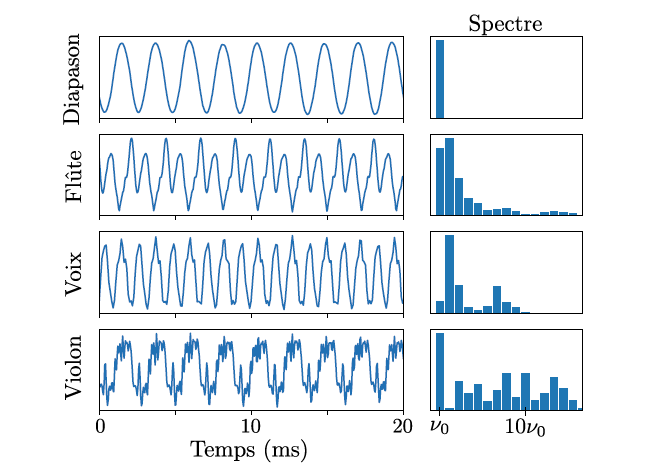

Nous n'avons pas trouvé de méthode analytique simple pour trouver la répartition des amplitudes des modes de notre instrument. C'est pourquoi nous avons décidé de la déterminer par la modélisation de sons déjà enregistrés.

In [10]:
class project:
    def __init__(self, wav_file_names,ref_frecs):
        
        self.wav_file_names = wav_file_names
        self.ref_frecs = ref_frecs

        self.sample_rates = np.ones(len(wav_file_names))
        self.data = []
        self.leftdata = []
        self.rightdata = []
        self.data_time = []

        self.fourier_A = []
        self.fourier_f = []
        self.fourier_phi = []
    
    def read_wav(self):
        """Lit des fichiers wav à partir d'une liste des noms des fichiers"""
        nb_files = len(self.wav_file_names)

        # Lecture d'un seul fichier
        if nb_files == 1:

            # Lecture du fichier
            sample_rate, data = spyo.wavfile.read(self.wav_file_names[0])
            data = data.T

            time = np.linspace(0., data.size, data.size)/sample_rate
            self.data_time = time

            # Met les données comme attribut de l'objet
            self.sample_rates = sample_rate
            self.leftdata = data[0]; self.rightdata = data[1]
            self.data = data

            # Reading info
            print("Rappel: Data format = (Channel, Data)")
            print("Solo")
            print("Data shape", data.shape)

        # Lecture de plusieurs pistes
        elif nb_files > 1:
            
            self.sample_rates = np.ones(nb_files)
            self.data.clear()
            self.leftdata.clear()
            self.rightdata.clear()
            self.data_time.clear()

            for i in range(nb_files):
                self.sample_rates[i], data = spyo.wavfile.read(self.wav_file_names[i])
                data = data.T

                time = np.linspace(0., data[1].size, data[1].size)/self.sample_rates[i]

                self.data.append(data)
                self.leftdata.append(data[0])
                self.rightdata.append(data[1])
                self.data_time.append(time)

            # Reading info
            #print("Dataformat: (Channel, Data)")
            print("Data: Multi")
            print("Number of data ", len(self.data))


    def fourier_transf(self, i=1, show = True):
        """Réalise la transformée de Fourier et cherche les pics"""

        x = np.array(self.rightdata[i]/np.max(abs(self.rightdata[i]))) # Normalisation du signal
        time = self.data_time[i]                                       # Time

        duration = np.max(time)
        freq = 1/self.sample_rates[i]
        N = int(duration/freq)

        # Calcul de la fft
        X  = fft(x)                         # Amplitudes en complexe (real et imag separés)
        f = fftfreq(x.size, d=freq)         # Fréquences de la transformée
        A = np.sqrt(X.real**2 + X.imag**2)  # Amplitude (module de la fft)
        print("Transformée réalisée!")

        
        # Filtrage des fréquences
        f_filter = np.logical_and(f>self.ref_frecs[i], f<2000) #Filtre entre la première harmonique attendue et 
                                                               #la fréquence maximale du son pour une guitare acoustique
        A    = A[f_filter]
        frec = f[f_filter]
        
        # Calcul des pics
        mode_peaks, properties = find_peaks(A, height = 8, distance = 500)

        A_mode_peaks = A[mode_peaks]
        f_mode_peaks = frec[mode_peaks]
        phi_mode_peaks = np.arctan2(X.real[f_filter][mode_peaks],X.imag[f_filter][mode_peaks]) 

        self.fourier_A.append(A_mode_peaks)
        self.fourier_f.append(f_mode_peaks)
        self.fourier_phi.append(phi_mode_peaks)

        # Tracé des graphiques
        if show == True:
            # Détermination des titres des graphes pour chaque note
            title2 = "Pics d'amplitudes transformée de Fourier " + self.wav_file_names[i]
            title3 = "Harmoniques transformée de Fourier " + self.wav_file_names[i]

            plt.figure(figsize=(12, 3))

            #Pics d'amplitudes
            plt.subplot(1, 2, 1)
            plt.scatter(frec, A, marker='.', s=0.3, label="Module")
            plt.scatter(f_mode_peaks, A_mode_peaks, marker='x', label="Peaks")
            plt.xlabel(r"Fréquence (Hz)")
            plt.ylabel(r"Amplitude $X(f)$")
            plt.title(title2)
            plt.xlim(0,1750)
            plt.legend()

            #Détermination des harmoniques et comparaison avec les multiples de la fondamentale
            plt.subplot(1, 2, 2)
            f_armonic1 = f_mode_peaks[A_mode_peaks == np.max(A_mode_peaks)]
            plt.plot(frec, A, label="Module")
            plt.axvline(f_armonic1, linestyle='--', color='r', alpha=0.7, linewidth=0.7, label='Fondamentale')
            plt.axvline(2 * f_armonic1, linestyle='--', color='teal', alpha=0.7, linewidth=0.7, label='Deuxième harmonique')
            plt.axvline(3 * f_armonic1, linestyle='--', color='b', alpha=0.7, linewidth=0.7, label='Troisième harmonique')
            plt.xlabel(r"Fréquence (Hz)")
            plt.ylabel(r"Amplitude $X(f)$")
            plt.title(title3)
            plt.xlim(0,1750)
            plt.legend()

            plt.tight_layout()
            plt.show()

        
        return A_mode_peaks,f_mode_peaks,phi_mode_peaks


### 1. Enregistrement et lecture des enregistrements 

Premièrement, nous avons enrégistré 6 notes jouées avec une guitare accoustique (uniquement les notes "*naturelles*" : mi, la ré, sol, si, mi). 

Puis, nous avons transformé les audios en des tableaux numpy contennant les valeurs d'amplitudes de l'onde de surpression de chaque note au cours du temps afin de pouvoir effectuer le traitement avec python. 

In [11]:
fileNames = ["La.wav","Mi maj.wav", "Mi.wav", "Re.wav", "Si.wav", "Sol.wav"]
ref_frecs = [100,81,320,140,240,190] # fréquences cibles des notes en Hz
project1 = project(fileNames,ref_frecs)

# Lecture des enregistrements
project1.read_wav()

Data: Multi
Number of data  6


Voici un réprésentation graphique des signaux récupérés:

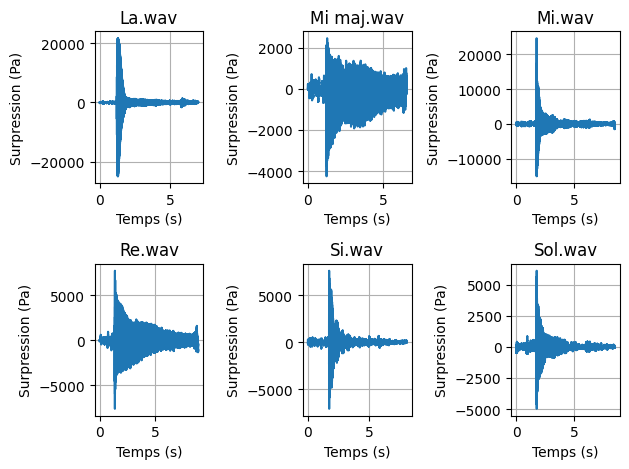

In [12]:
# Plot des figures
for i in range(len(fileNames)):
    plt.subplot(2,3,i+1)
    plt.plot(project1.data_time[i],project1.rightdata[i])
    title =fileNames[i]
    plt.title(title)
    plt.grid()
    plt.xlabel("Temps (s)"); plt.ylabel("Surpression (Pa)")
plt.tight_layout()
plt.show()

### 2. Modélisation et traitement du signal 

Le signal sonore $y_{tot}$, comme expliqué précédemment est une superposition d'ondes sinusoïdales stationnaires : les modes de vibration. 

Le profil temporel des ondes de surpression (à position fixe) peut s'exprimer ainsi :  
$$y_{tot} = \sum^{k}_{n=1} A_n \cos(\omega_n t + \phi_n) = \sum^{k}_{n=1} y_{n}$$

avec chaque mode ($y_{n}$):  
$$y_{n} = A_n \cos(\omega_n t + \phi_n)= A_n \cos( 2 \pi \nu_n t + \phi_n)$$

$A_n$ l'amplitude, $\nu_{n}$ la fréquence et $\phi_n$ la phase du mode.

Dans cette partie, on cherche donc à déterminer les paramètres inconnus de chaque mode: l'amplitude ($A_n$), la fréquence ($\nu_{n}$) et la phase ($\phi_n$) à partir des enregistrements réalisés, pour ensuite reconstituer le son à l'aide du modèle ennoncé précédemment.
Cette décomposition d'amplitudes en fonction de la fréquence peut être donnée par la transformée de Fourier du signal enrégistré.

Etant donné que l'on travaille avec de données discrètes on utilisera la *transformée de Fourier discrète*. 

On utilise les fréquences fondamentales des différentes notes et leurs mutiples (premières harmoniques) afin de réaliser le traitement :

__Tableau des fréquences fondamentales des notes "narutelles" d'une guitare__

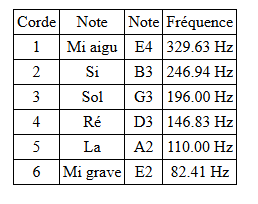


Transformée réalisée!


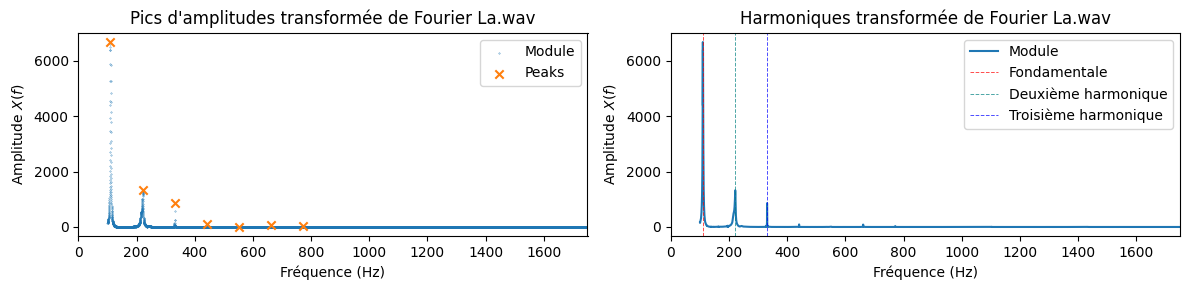

Transformée réalisée!


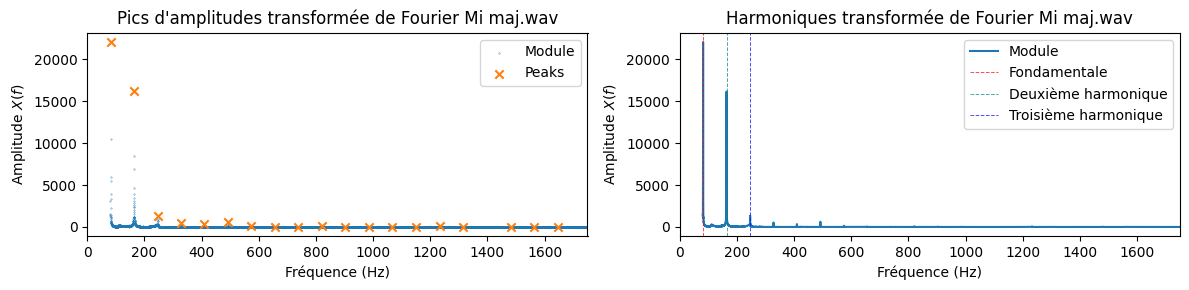

Transformée réalisée!


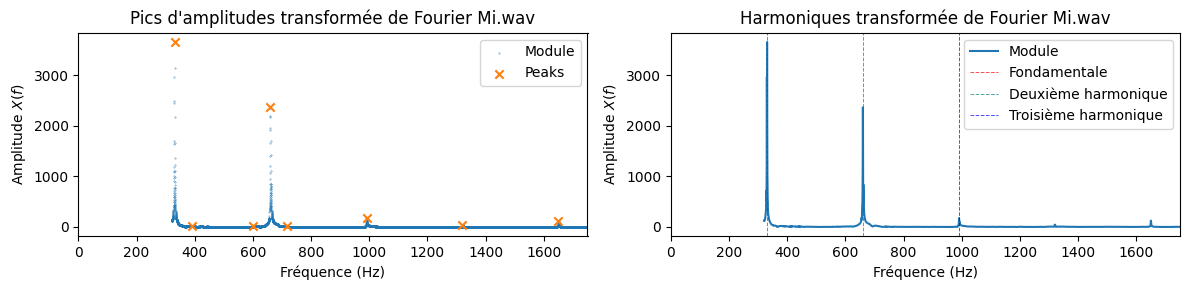

Transformée réalisée!


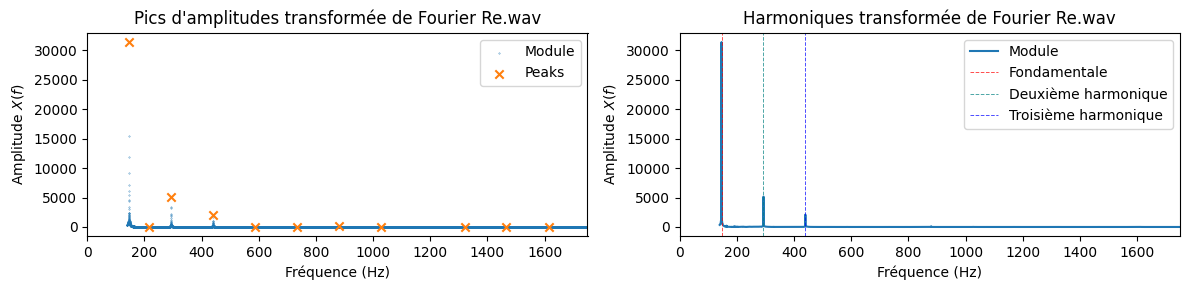

Transformée réalisée!


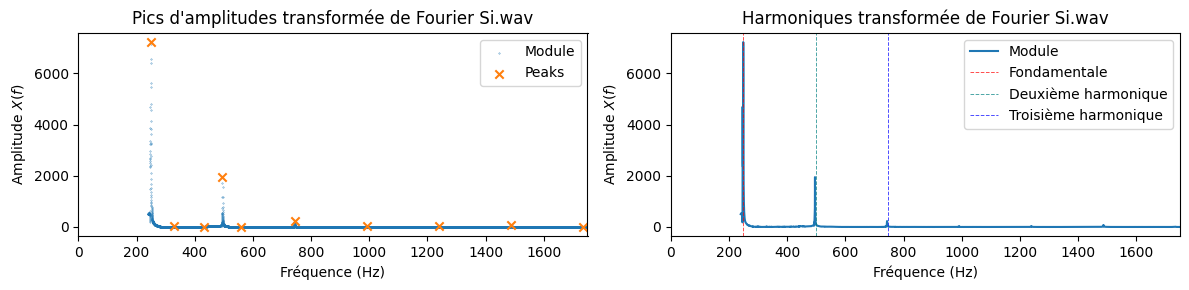

Transformée réalisée!


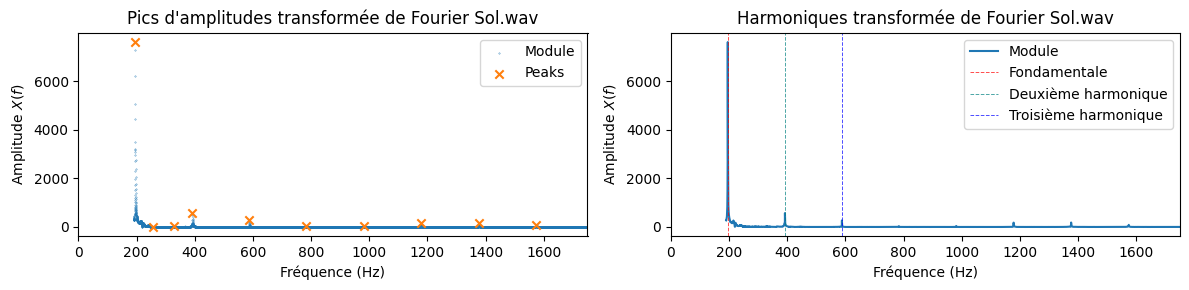

In [13]:
for k in range(len(fileNames)):
    project1.fourier_transf(i=k)

### 3. Simulation du signal 

Une fois les amplitudes, fréquences et phases extraites pour chaque mode, on peut enfin s'attaquer à la modélisation de l'onde de surpression pour chacun des modes.
Afin de se rapprocher du son réellement produit par une guitare, on peut, comme pour la partie précédente, appliquer un amortissement ainsi qu'une attaque.

Pour l'amortissement on a choissi une fonction en cloche que l'on applique individuellement à chacun des modes, afin qu'ils ne soient pas tous amortis de la même manière, et ainsi mieux simuler le timbre. Les paramètres ont été déterminés manuellement en écoutant les sons produits.

$$\text{decay(t)} = \frac {1} {1+(\frac {t} {0.15})^{2}}$$ 
$$\text{attack(t)} = \frac {t} {0.05}$$ 

Finnalement on sommera les modes sur $n$ pour produire le signal final.

In [21]:


def sim_model(A,f,phi,t):
     return A*np.cos(2*np.pi*f*t + phi)

def amort_gauss(t):
     """Amortissement de type Lorentzien"""
     return (1/(1+(t/0.15)**2))

def damped_model(A, f, phi, t):
    """Amortissement dépendant de la fréquence"""
    #Ajout d'une attaque comme précedemment
    attack = np.linspace(0, 1, int(0.05 * sample_rate)) # tableau de valeurs grandissant linéairement entre 0 et 1 jusqu'à 0.1s
    t_fin = np.linspace(0, 5, len(t)-len(attack))       # tableau de temps allant de 0.1s à la fin de l'enregistrement
    decay = amort_gauss(t_fin)
    
    return sim_model(A, f, phi, t)* np.concatenate((attack,decay))

def note_simulator(As,fs,phases,note_index, waittime = True, amort = True):
      """Calcul de l'onde de chaque note et ajout ensemble""" 
      y_n = []
      for i in range(len(As)):
            time_ = project1.data_time[note_index] #Détermination de la durée de chaque enregistrement
            if amort == True:
                 y = damped_model(As[i],fs[i],phases[i],time_) #Ajout d'un amortissement
            else:
                 y = sim_model(As[i],fs[i],phases[i],time_) #Calcul du mode selon le modèle
            
            if waittime == True: #Ajout d'une phase de silence pour un démarrage "doux"
                t  = 0.5 #s
                silence = np.zeros(int(t*project1.sample_rates[0]))
                y = np.concatenate((silence,y), axis = 0)

            y_n.append(y)
      return np.sum(y_n, axis = 0) #Somme sur les modes
      

In [15]:
notes = []
for i in range(len(project1.wav_file_names)): #Calcul de l'onde de surpression résultante pour chaque note en utilisant les fonctions plus haut
    y = note_simulator(project1.fourier_A[i][0:10],project1.fourier_f[i][0:10],project1.fourier_phi[i][0:10],i)
    notes.append(y)

Une fois le signal final produit, peut enfin transformer le tableau numpy d'amplitudes en audio format "wav" pour pouvoir les écouter.

In [16]:
names = ["La", "Mi maj", "Mi", "Re", "Si", "Sol"]
for i in range(len(project1.wav_file_names)): #Sauvegarde au format wav
    name = names[i] + " simulé.wav" 
    save_wav(notes[i],name)

Voici une allure des signaux produits :

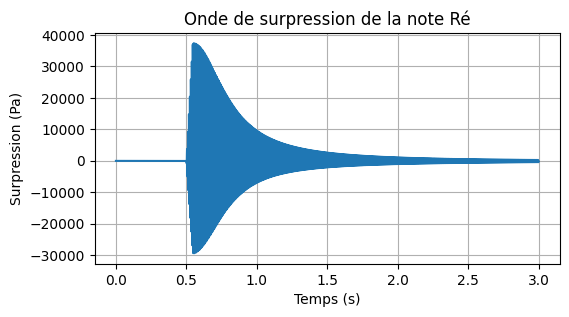

In [17]:
plt.figure(figsize = (6,3))
plt.plot(project1.data_time[3][0:int(3*project1.sample_rates[3])],notes[3][0:int(3*project1.sample_rates[3])])
plt.grid()
plt.ylabel("Surpression (Pa)"); plt.xlabel("Temps (s)")
plt.title("Onde de surpression de la note Ré")
plt.show()

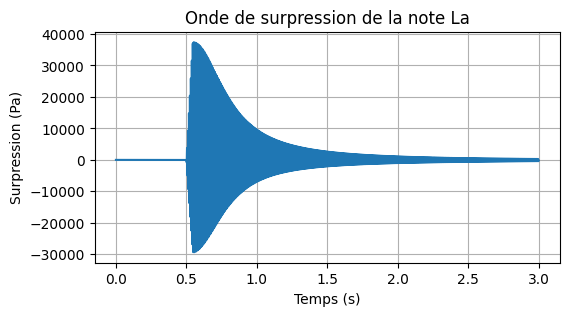

In [18]:
plt.figure(figsize = (6,3))
plt.plot(project1.data_time[0][0:int(3*project1.sample_rates[0])],notes[3][0:int(3*project1.sample_rates[0])])
plt.grid()
plt.ylabel("Surpression (Pa)"); plt.xlabel("Temps (s)")
plt.title("Onde de surpression de la note La")
plt.show()

## Conclusion

Par la première méthode, nous avons obtenu un son assez étrange, plus proche d'un diapason que d'une guitare. C'est lié à plusieurs facteurs :
- On entend le profil temporel de l'onde de déplacement sur la corde, et non pas l'onde acoustique de surpression, qui est le son réellement audible. Nous n'avons pas pris en compte la transmission à l'air par la caisse de résonance de la guitare
- Les conditions initiales peuvent être trop peu réalistes, faussant la détermination des coefficients de fourier. Par exemple, on trouve que les $C_n$ sont nuls et qu'il n'y a donc pas de modes pairs, alors que pour les transformées des enregistrements, on a bien un mode pour chaque $n$.

Par la seconde méthode, le son obtenu se rapproche de celui d'une guitare pour certains notes (notamment les notes graves), mais nettemment moins pour d'autres. 
- Une amélioration possible serait de prendre en compte le caisse de résonance. En effet, lorsqu’on réalise la transformée discrète, on a des pics en dessous de la fréquence cible du mode fondamental mais tout de même dans le spectre audible, que l’on suppose être liés à la vibration de la caisse de résonance et donc la transmission du son à l’air. Il serait intéressant de le prendre en compte. 
- Nous avons réalisé les enregistrements avec un bon microphone, mais des bruits parasites ont pu être enregistrés. Une autre manière de procéder serait d’enregistrer directement le signal électrique sur une guitare, sans passer par la transmission par l’air
- Enfin, on pourrait également améliorer notre modèle d’amortissement en le modifiant selon la fréquence du mode, en plus de le faire individuellement pour chaque mode. Cela nous permettrait de rendre compte du fait que l’amortissement est différent pour chaque mode.


## Références

**Documentation utilisée**

Lecture et enregistrement des audios en format wav:

- https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.write.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html

Sample rates et discrétisation d'un signal:

- https://www.izotope.com/en/learn/digital-audio-basics-sample-rate-and-bit-depth.html#:~:text=Sample%20rate%20is%20the%20number,frequencies%20captured%20in%20digital%20audio

Rang de fréquences fondamentales d'une guitare:
- https://www.guitarristas.info/foros/duda-rango-frecuencias-instrumentos/328840

Simulation d'un signal & filtre passe bas :
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html#scipy.signal.butter
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html#scipy.signal.filtfilt

Transformée de fourier discrète
- https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

Valeur des paramètres du modèle
- https://www.stringtensioncalculator.com/what-is-guitar-string-tension/
- http://physique.chimie.vds.free.fr/

__Autres__:
- _Notes de Cours LU2PY421_ (Ondes et electromagnétisme) - Clément Sayrin, 24/03/2025 
- _Notes de Cours LU2PY220, LU20Y520_ (Mathématiques complémentaires) - Jean Noël Aqua et al. 2024-2025
- _Travaux dirigés LU2PY220, LU20Y520_ (Mathématiques complémentaires) - Jean Noël Aqua et al. 2024-2025

Conseil pour le traitement numérique des signaux:
- María Victoria Castillo Montesino (Ingénieure en télecomunications)